# 🍎 Apple Prices — Estudio de Data Science con Pandas

**Dataset:** `apple_prices_dataset.csv`  
**Autor:** Borja  
**Fecha:** Marzo 2026  

---

## 📋 Descripción del dataset

Datos de ventas de manzanas en diferentes países y mercados con las siguientes variables:

| Columna | Tipo | Descripción |
|---|---|---|
| `Record_ID` | int | Identificador único |
| `Date` | date | Fecha de la transacción |
| `Country` | str | País de venta |
| `Apple_Variety` | str | Variedad de manzana |
| `Quality_Grade` | str | Calidad: Economy / Standard / Premium |
| `Market_Type` | str | Canal de venta |
| `Price_per_KG_USD` | float | Precio por kg en dólares |
| `Quantity_Sold_KG` | int | Cantidad vendida en kg |
| `Revenue_USD` | float | Ingresos en dólares |

---

## 📚 Índice
1. **Setup y carga de datos**
2. **Exploración inicial (EDA)**
3. **Limpieza y preparación de datos**
4. **Análisis estadístico descriptivo**
5. **Análisis por grupo (groupby)**
6. **Análisis temporal**
7. **Correlación y heatmap**
8. **Detección de outliers**
9. **Ingeniería de características (Feature Engineering)**
10. **Modelo predictivo: Regresión lineal del Revenue**
11. **Conclusiones y findings clave**

---
## 1. 🔧 Setup y carga de datos

In [1]:
# ── Instalación de dependencias (ejecutar solo si es necesario) ──
# !pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# ── Configuración visual ──
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print('✅ Librerías cargadas correctamente')
print(f'📅 Análisis ejecutado: {datetime.now().strftime("%Y-%m-%d %H:%M")}')

✅ Librerías cargadas correctamente
📅 Análisis ejecutado: 2026-03-06 18:45


In [2]:
# ── Carga del dataset ──
df = pd.read_csv('apple_prices_dataset.csv', parse_dates=['Date'])

print(f'📦 Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head(10)

📦 Dataset cargado: 500 filas × 9 columnas


,Record_ID,Date,Country,Apple_Variety,Quality_Grade,Market_Type,Price_per_KG_USD,Quantity_Sold_KG,Revenue_USD
0,1,2024-11-27,Brazil,Gala,Premium,Supermarket,4.31,858,3697.98
1,2,2025-01-09,Japan,Fuji,Premium,Supermarket,2.96,1913,5662.48
2,3,2025-03-20,Canada,Red Delicious,Standard,Supermarket,2.35,542,1273.70
3,4,2025-08-02,Brazil,Golden Delicious,Economy,Supermarket,1.26,507,638.82
4,5,2025-08-13,Germany,Gala,Economy,Wholesale Market,2.97,151,448.47
5,6,2024-10-23,Canada,Red Delicious,Standard,Wholesale Market,2.35,1157,2718.95
6,7,2024-04-15,Germany,Honeycrisp,Premium,Supermarket,2.95,1358,4006.10
7,8,2025-07-31,China,Golden Delicious,Economy,Online Store,1.02,471,480.42
8,9,2024-11-17,China,Honeycrisp,Standard,Wholesale Market,2.52,1941,4891.32
9,10,2024-07-03,Canada,Red Delicious,Standard,Online Store,3.39,549,1861.11


---
## 2. 🔍 Exploración inicial (EDA)

In [3]:
# ── Información estructural del DataFrame ──
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Record_ID         500 non-null    int64         
 1   Date              500 non-null    datetime64[ns]
 2   Country           500 non-null    object        
 3   Apple_Variety     500 non-null    object        
 4   Quality_Grade     500 non-null    object        
 5   Market_Type       500 non-null    object        
 6   Price_per_KG_USD  500 non-null    float64       
 7   Quantity_Sold_KG  500 non-null    int64         
 8   Revenue_USD       500 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 35.3+ KB


In [4]:
# ── Valores únicos por variable categórica ──
cat_cols = ['Country', 'Apple_Variety', 'Quality_Grade', 'Market_Type']
for col in cat_cols:
    vals = df[col].unique()
    print(f'🏷️  {col} ({len(vals)} únicos): {sorted(vals)}')

🏷️  Country (13 únicos): ['Australia', 'Brazil', 'Canada', 'China', 'France', 'Germany', 'India', 'Italy', 'Japan', 'Saudi Arabia', 'UAE', 'UK', 'USA']
🏷️  Apple_Variety (7 únicos): ['Fuji', 'Gala', 'Golden Delicious', 'Granny Smith', 'Honeycrisp', 'Pink Lady', 'Red Delicious']
🏷️  Quality_Grade (3 únicos): ['Economy', 'Premium', 'Standard']
🏷️  Market_Type (4 únicos): ['Local Market', 'Online Store', 'Supermarket', 'Wholesale Market']


In [5]:
# ── Rango temporal del dataset ──
print(f'📅 Fecha mínima : {df["Date"].min().date()}')
print(f'📅 Fecha máxima : {df["Date"].max().date()}')
print(f'⏱️  Periodo total : {(df["Date"].max() - df["Date"].min()).days} días')
print(f'\n🌍 Países ({df["Country"].nunique()}): {sorted(df["Country"].unique())}')

📅 Fecha mínima : 2024-01-01
📅 Fecha máxima : 2025-12-31
⏱️  Periodo total : 730 días

🌍 Países (13): ['Australia', 'Brazil', 'Canada', 'China', 'France', 'Germany', 'India', 'Italy', 'Japan', 'Saudi Arabia', 'UAE', 'UK', 'USA']


---
## 3. 🧹 Limpieza y preparación de datos

In [6]:
# ── Verificación de valores nulos ──
nulos = df.isnull().sum()
print('🔎 Valores nulos por columna:')
print(nulos[nulos > 0] if nulos.any() else '✅ No hay valores nulos')

🔎 Valores nulos por columna:
✅ No hay valores nulos


In [7]:
# ── Verificación de duplicados ──
dups = df.duplicated().sum()
print(f'🔎 Filas duplicadas: {dups}')
if dups > 0:
    df = df.drop_duplicates()
    print(f'✅ Duplicados eliminados. Nuevo tamaño: {df.shape}')

🔎 Filas duplicadas: 0


In [8]:
# ── Verificación de consistencia: Revenue = Price × Quantity ──
df['Revenue_Calc'] = (df['Price_per_KG_USD'] * df['Quantity_Sold_KG']).round(2)
discrepancias = df[abs(df['Revenue_USD'] - df['Revenue_Calc']) > 0.01]
print(f'⚠️  Filas con discrepancia de Revenue: {len(discrepancias)}')
df = df.drop(columns=['Revenue_Calc'])  # Columna auxiliar eliminada

# Ordenar por fecha
df = df.sort_values('Date').reset_index(drop=True)
print('✅ Datos listos para análisis')

⚠️  Filas con discrepancia de Revenue: 0
✅ Datos listos para análisis


---
## 4. 📊 Análisis estadístico descriptivo

In [9]:
# ── Estadísticas descriptivas de variables numéricas ──
df[['Price_per_KG_USD', 'Quantity_Sold_KG', 'Revenue_USD']].describe().T

,count,mean,std,min,25%,50%,75%,max
Price_per_KG_USD,500.00,2.67,1.07,0.81,1.74,2.69,3.60,4.49
Quantity_Sold_KG,500.00,1020.46,578.57,50.00,511.25,1044.00,1534.25,1999.00
Revenue_USD,500.00,2661.85,1887.39,49.50,1165.86,2330.27,3840.61,8461.56


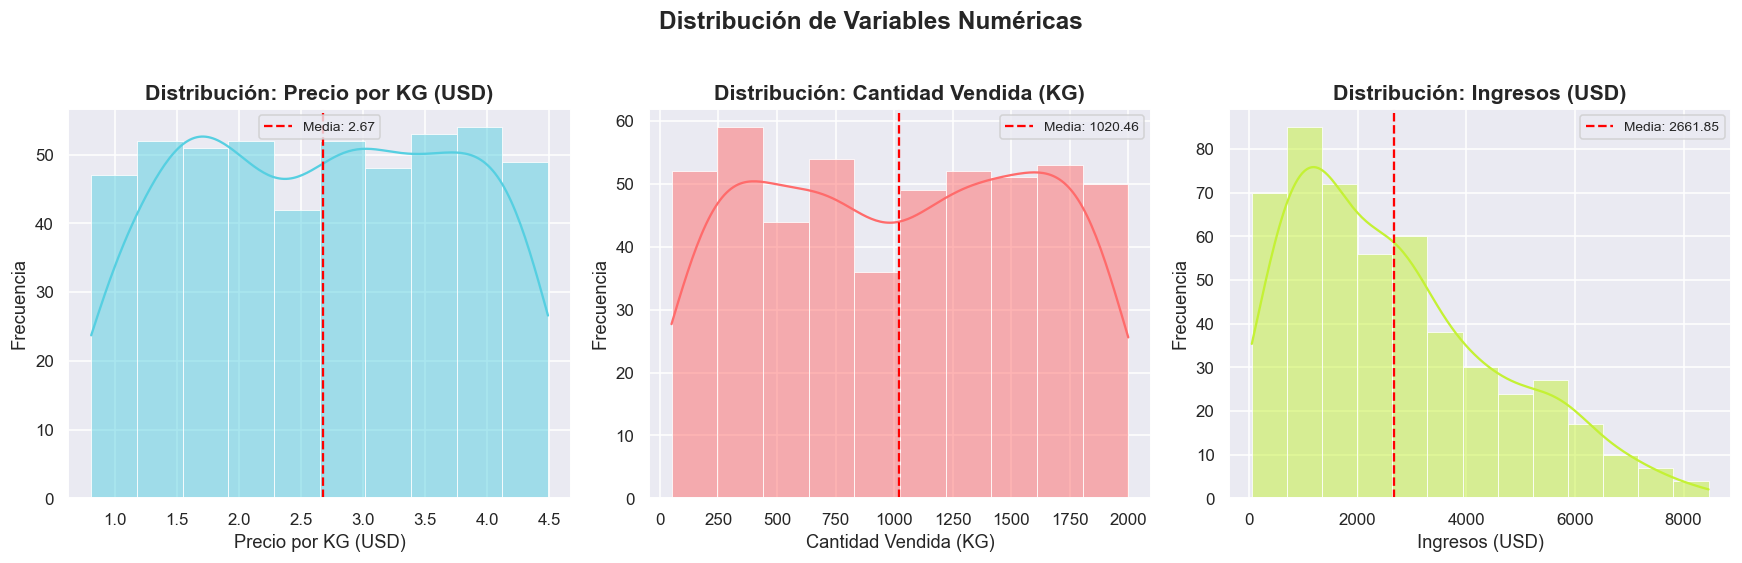

In [10]:
# ── Distribuciones de las 3 variables numéricas ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cols = ['Price_per_KG_USD', 'Quantity_Sold_KG', 'Revenue_USD']
colors = ['#56CFE1', '#FF6B6B', '#C4F135']
titles = ['Precio por KG (USD)', 'Cantidad Vendida (KG)', 'Ingresos (USD)']

for ax, col, color, title in zip(axes, cols, colors, titles):
    sns.histplot(df[col], kde=True, ax=ax, color=color, edgecolor='white', linewidth=0.5)
    ax.set_title(f'Distribución: {title}')
    ax.set_xlabel(title)
    ax.set_ylabel('Frecuencia')
    # Añadir línea de media
    mean_val = df[col].mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Media: {mean_val:.2f}')
    ax.legend(fontsize=9)

plt.suptitle('Distribución de Variables Numéricas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

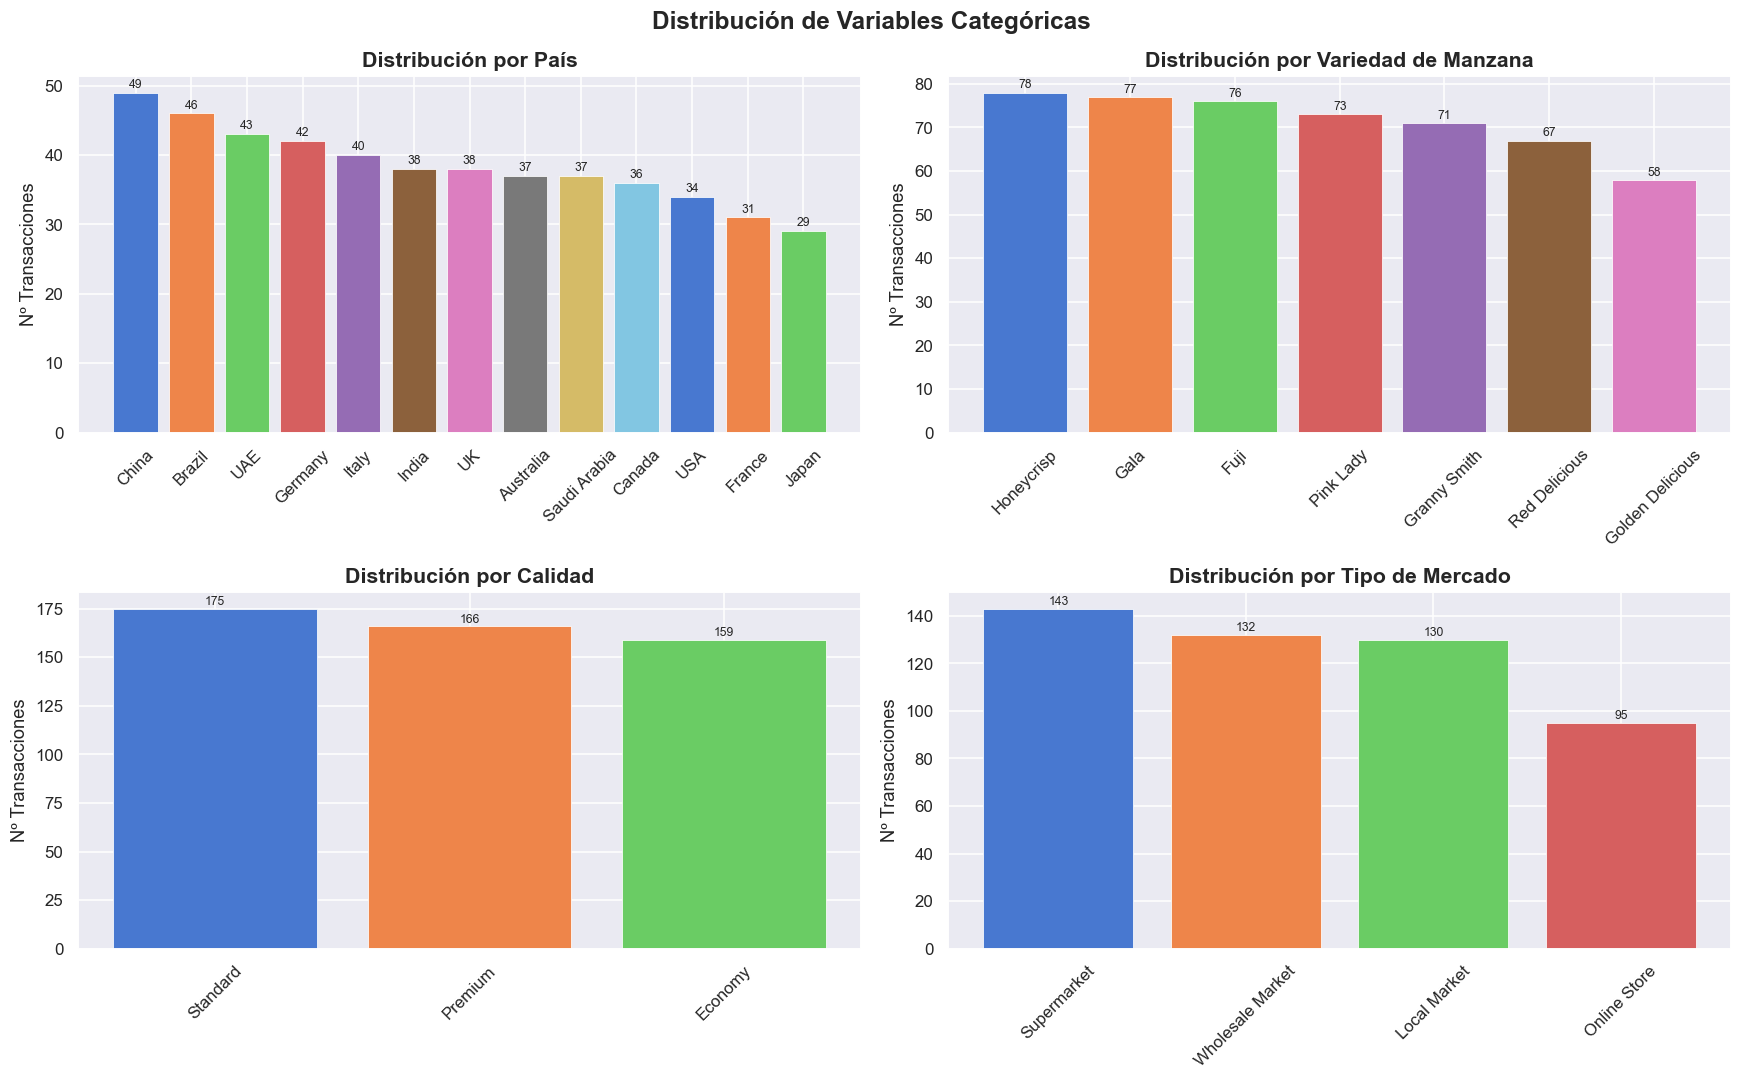

In [11]:
# ── Conteo y distribución de variables categóricas ──
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
cat_titles = ['País', 'Variedad de Manzana', 'Calidad', 'Tipo de Mercado']

for ax, col, title in zip(axes.flatten(), cat_cols, cat_titles):
    counts = df[col].value_counts()
    colors_bar = sns.color_palette('muted', len(counts))
    ax.bar(counts.index, counts.values, color=colors_bar, edgecolor='white', linewidth=0.5)
    ax.set_title(f'Distribución por {title}')
    ax.set_ylabel('Nº Transacciones')
    ax.tick_params(axis='x', rotation=45)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.3, str(v), ha='center', va='bottom', fontsize=8)

plt.suptitle('Distribución de Variables Categóricas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. 🔄 Análisis por grupo (GroupBy)

In [12]:
# ── Revenue total y precio medio por País ──
by_country = df.groupby('Country').agg(
    Total_Revenue=('Revenue_USD', 'sum'),
    Avg_Price=('Price_per_KG_USD', 'mean'),
    Total_Qty=('Quantity_Sold_KG', 'sum'),
    Num_Transactions=('Record_ID', 'count')
).sort_values('Total_Revenue', ascending=False)

by_country['Total_Revenue'] = by_country['Total_Revenue'].round(2)
by_country['Avg_Price'] = by_country['Avg_Price'].round(3)
print('💰 Revenue total y estadísticas por País:')
by_country

💰 Revenue total y estadísticas por País:


,Total_Revenue,Avg_Price,Total_Qty,Num_Transactions
Country,,,,
China,149148.82,2.78,53233,49
Germany,124117.08,2.96,45602,42
UAE,110790.44,2.55,46317,43
UK,108821.03,2.86,40339,38
Brazil,103367.48,2.42,42278,46
Saudi Arabia,100835.50,2.69,39308,37
Canada,99437.85,2.74,33883,36
France,99131.38,2.91,34555,31
India,95698.61,2.74,36144,38


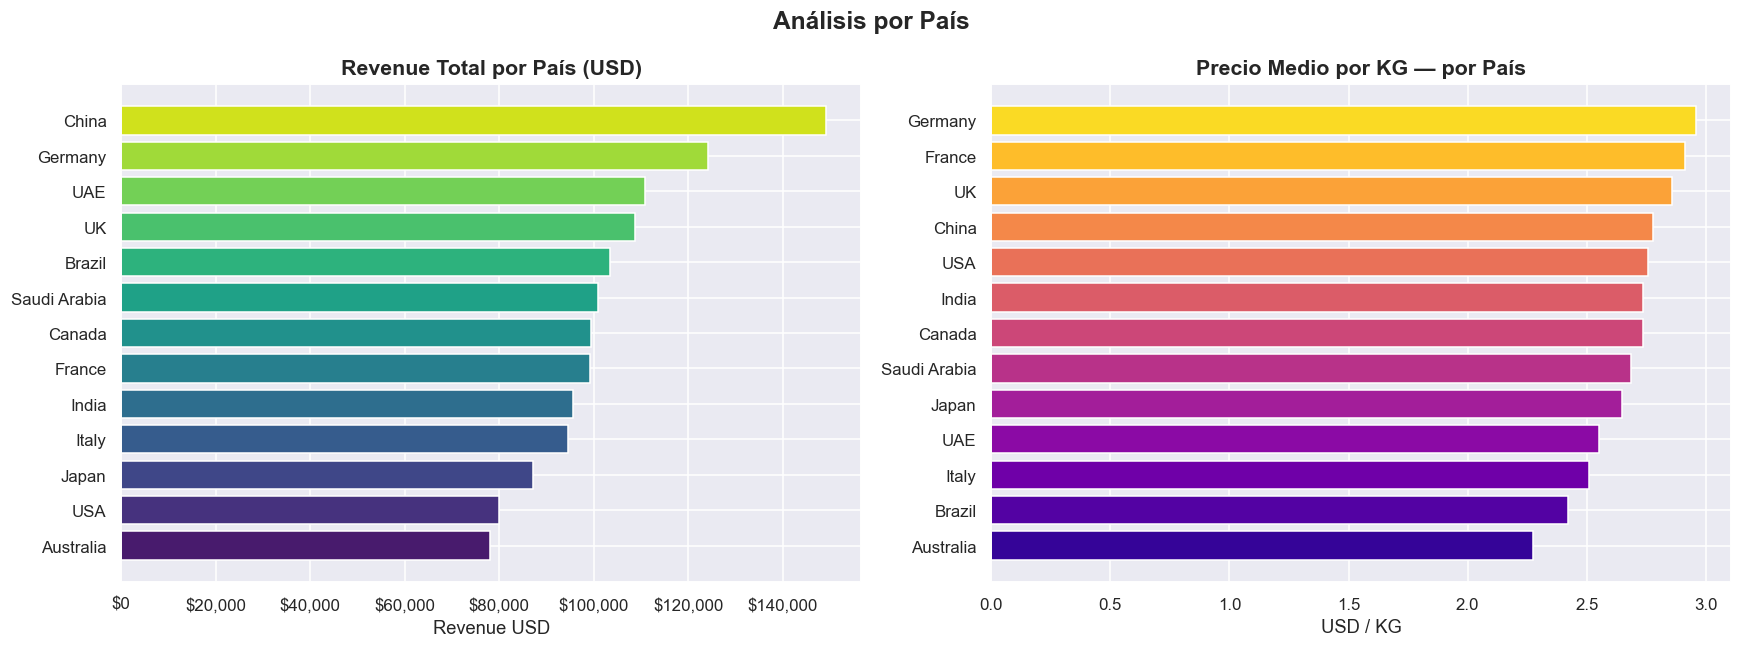

In [13]:
# ── Visualización: Top países por Revenue ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Revenue total
top = by_country.sort_values('Total_Revenue', ascending=True)
palette = sns.color_palette('viridis', len(top))
ax1.barh(top.index, top['Total_Revenue'], color=palette)
ax1.set_title('Revenue Total por País (USD)')
ax1.set_xlabel('Revenue USD')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Precio medio por país
top2 = by_country.sort_values('Avg_Price', ascending=True)
palette2 = sns.color_palette('plasma', len(top2))
ax2.barh(top2.index, top2['Avg_Price'], color=palette2)
ax2.set_title('Precio Medio por KG — por País')
ax2.set_xlabel('USD / KG')

plt.suptitle('Análisis por País', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# ── Precio medio por Variedad y Calidad ──
pivot_price = df.pivot_table(
    values='Price_per_KG_USD',
    index='Apple_Variety',
    columns='Quality_Grade',
    aggfunc='mean'
).round(2)

# Ordenar columnas de calidad
quality_order = ['Economy', 'Standard', 'Premium']
pivot_price = pivot_price[quality_order]

print('🍏 Precio medio (USD/KG) por Variedad y Calidad:')
pivot_price

🍏 Precio medio (USD/KG) por Variedad y Calidad:


Quality_Grade,Economy,Standard,Premium
Apple_Variety,,,
Fuji,2.17,2.60,2.78
Gala,2.79,2.93,2.94
Golden Delicious,2.46,2.60,2.80
Granny Smith,2.55,2.52,2.79
Honeycrisp,2.41,2.69,2.53
Pink Lady,2.60,2.62,3.01
Red Delicious,2.45,2.72,3.12


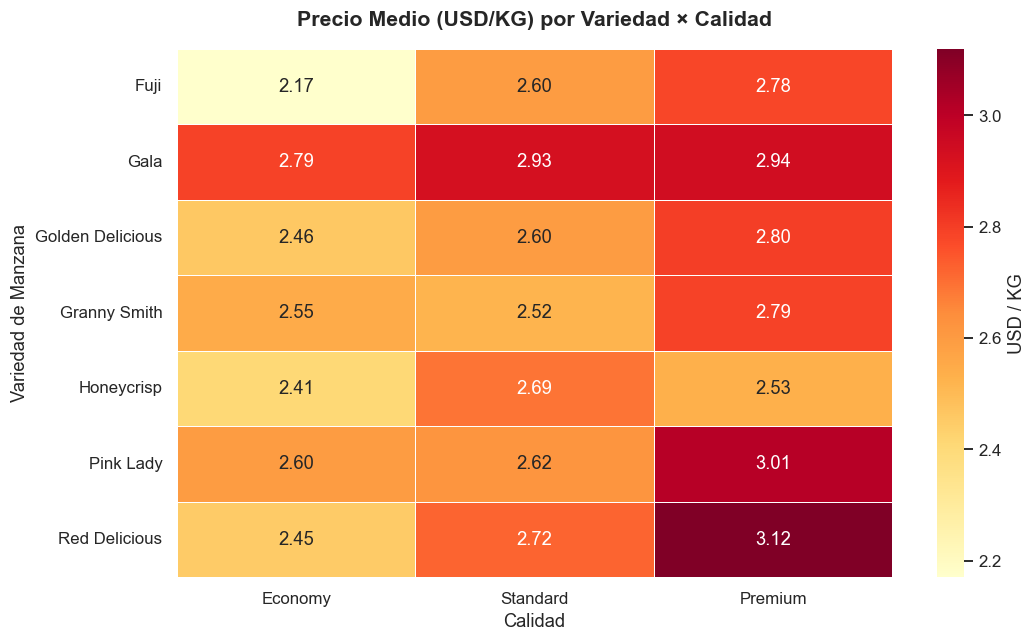

In [15]:
# ── Heatmap: Precio medio por Variedad × Calidad ──
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    pivot_price,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'USD / KG'}
)
ax.set_title('Precio Medio (USD/KG) por Variedad × Calidad', pad=15)
ax.set_xlabel('Calidad')
ax.set_ylabel('Variedad de Manzana')
plt.tight_layout()
plt.show()

🏪 Revenue por Tipo de Mercado:


,Total_Revenue,Avg_Revenue_per_tx,Transactions
Market_Type,,,
Supermarket,366894.89,2565.70,143
Wholesale Market,358324.63,2714.58,132
Local Market,350371.06,2695.16,130
Online Store,255335.87,2687.75,95


/var/folders/3c/_bgf9xt50ll121jxkyy_ckdm0000gn/T/ipykernel_30170/3743124018.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


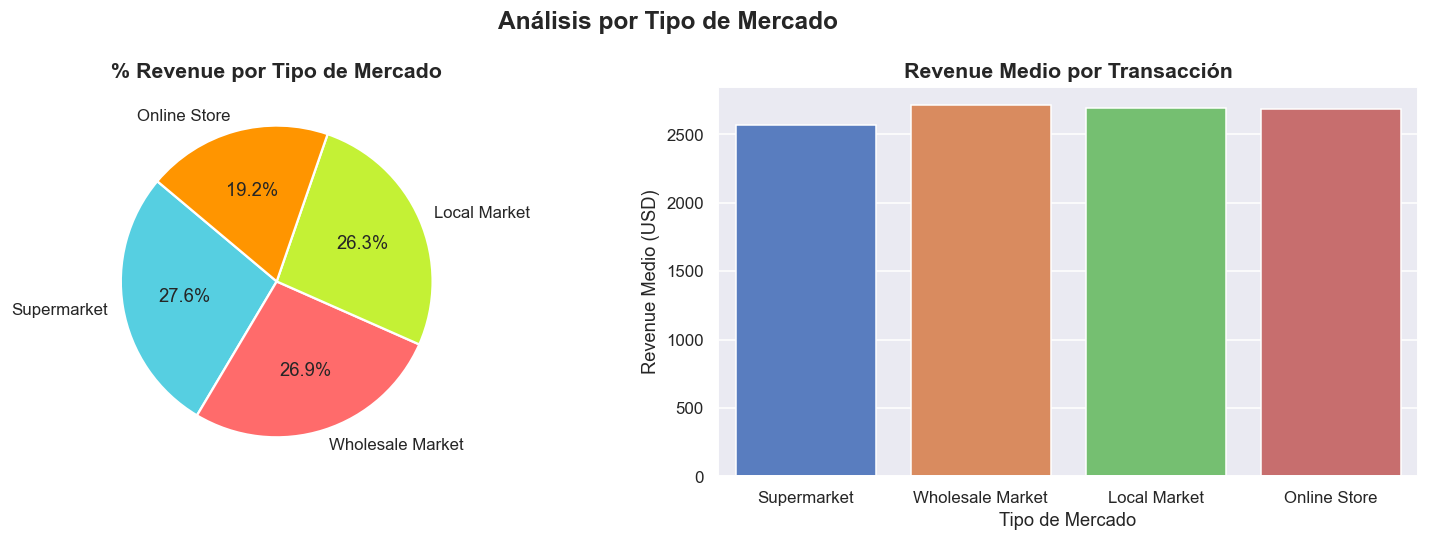

In [16]:
# ── Revenue por tipo de mercado ──
by_market = df.groupby('Market_Type').agg(
    Total_Revenue=('Revenue_USD', 'sum'),
    Avg_Revenue_per_tx=('Revenue_USD', 'mean'),
    Transactions=('Record_ID', 'count')
).sort_values('Total_Revenue', ascending=False).round(2)

print('🏪 Revenue por Tipo de Mercado:')
display(by_market)

# Pie chart de participación
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors_pie = ['#56CFE1', '#FF6B6B', '#C4F135', '#FF9500']

ax1.pie(
    by_market['Total_Revenue'],
    labels=by_market.index,
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
ax1.set_title('% Revenue por Tipo de Mercado')

sns.barplot(
    data=by_market.reset_index(),
    x='Market_Type',
    y='Avg_Revenue_per_tx',
    palette='muted',
    ax=ax2
)
ax2.set_title('Revenue Medio por Transacción')
ax2.set_xlabel('Tipo de Mercado')
ax2.set_ylabel('Revenue Medio (USD)')

plt.suptitle('Análisis por Tipo de Mercado', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

/var/folders/3c/_bgf9xt50ll121jxkyy_ckdm0000gn/T/ipykernel_30170/2931359420.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


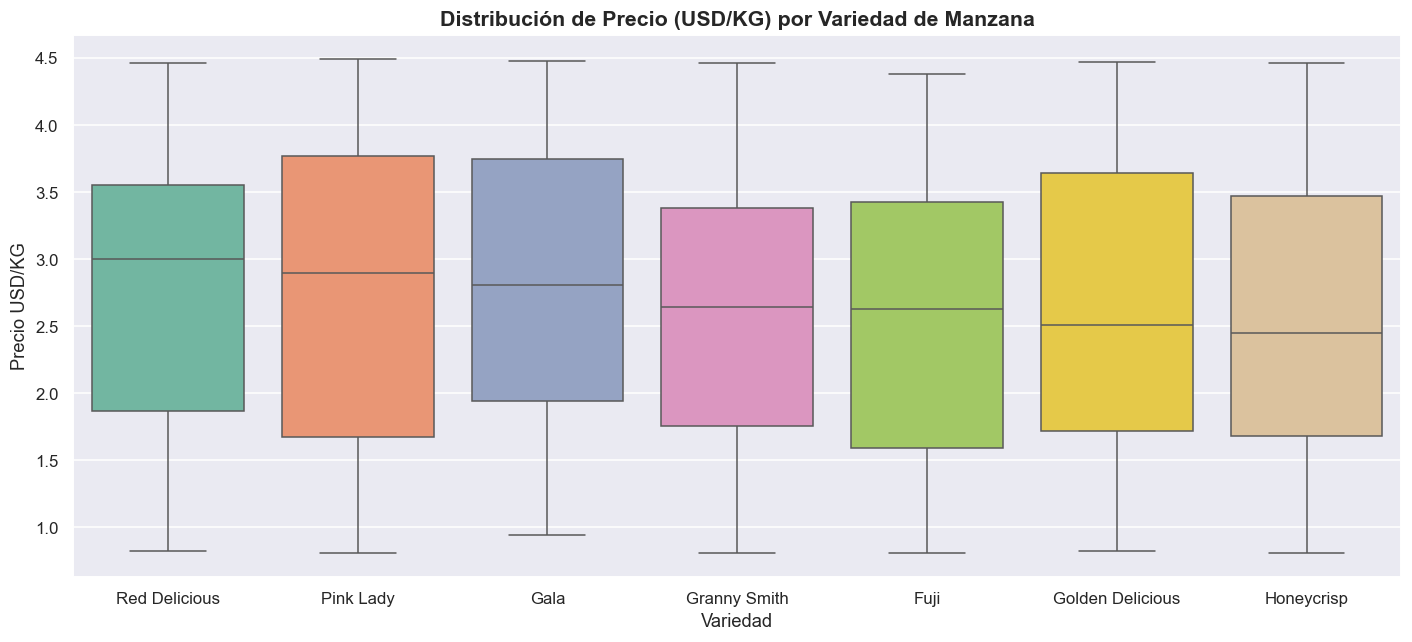

In [17]:
# ── Boxplot: precio por variedad ──
fig, ax = plt.subplots(figsize=(13, 6))
order = df.groupby('Apple_Variety')['Price_per_KG_USD'].median().sort_values(ascending=False).index
sns.boxplot(
    data=df,
    x='Apple_Variety',
    y='Price_per_KG_USD',
    order=order,
    palette='Set2',
    ax=ax,
    flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 4}
)
ax.set_title('Distribución de Precio (USD/KG) por Variedad de Manzana')
ax.set_xlabel('Variedad')
ax.set_ylabel('Precio USD/KG')
plt.tight_layout()
plt.show()

/var/folders/3c/_bgf9xt50ll121jxkyy_ckdm0000gn/T/ipykernel_30170/3309160650.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


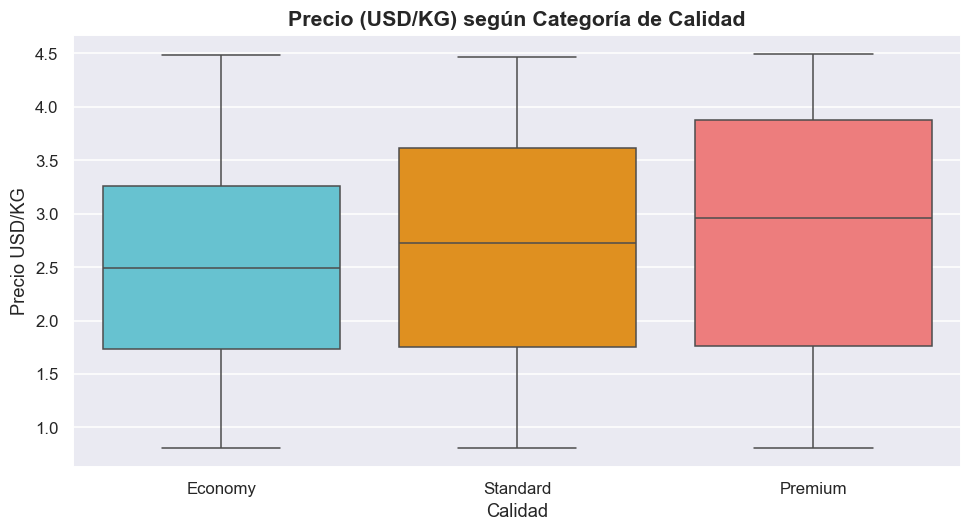


📊 Precio medio por calidad:
               mean  median  std
Quality_Grade                   
Economy        2.51    2.49 1.01
Premium        2.84    2.96 1.12
Standard       2.67    2.73 1.06


In [18]:
# ── Boxplot: precio por calidad ──
fig, ax = plt.subplots(figsize=(9, 5))
quality_order = ['Economy', 'Standard', 'Premium']
palette_q = {'Economy': '#56CFE1', 'Standard': '#FF9500', 'Premium': '#FF6B6B'}

sns.boxplot(
    data=df,
    x='Quality_Grade',
    y='Price_per_KG_USD',
    order=quality_order,
    palette=palette_q,
    ax=ax,
    flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 4}
)
ax.set_title('Precio (USD/KG) según Categoría de Calidad')
ax.set_xlabel('Calidad')
ax.set_ylabel('Precio USD/KG')
plt.tight_layout()
plt.show()

# Test: ¿Hay diferencia significativa en precios por calidad?
print('\n📊 Precio medio por calidad:')
print(df.groupby('Quality_Grade')['Price_per_KG_USD'].agg(['mean', 'median', 'std']).round(3))

---
## 6. 📅 Análisis temporal

In [19]:
# ── Ingeniería de fechas ──
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')
df['Quarter'] = df['Date'].dt.quarter
df['DayOfWeek'] = df['Date'].dt.dayofweek  # 0=Lunes

print('✅ Variables temporales creadas: Year, Month, Month_Name, Quarter, DayOfWeek')
df[['Date', 'Year', 'Month', 'Quarter', 'DayOfWeek']].head(5)

✅ Variables temporales creadas: Year, Month, Month_Name, Quarter, DayOfWeek


,Date,Year,Month,Quarter,DayOfWeek
0,2024-01-01,2024,1,1,0
1,2024-01-02,2024,1,1,1
2,2024-01-02,2024,1,1,1
3,2024-01-07,2024,1,1,6
4,2024-01-07,2024,1,1,6


/var/folders/3c/_bgf9xt50ll121jxkyy_ckdm0000gn/T/ipykernel_30170/1766157017.py:14: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniforge/base/envs/SAPAU/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


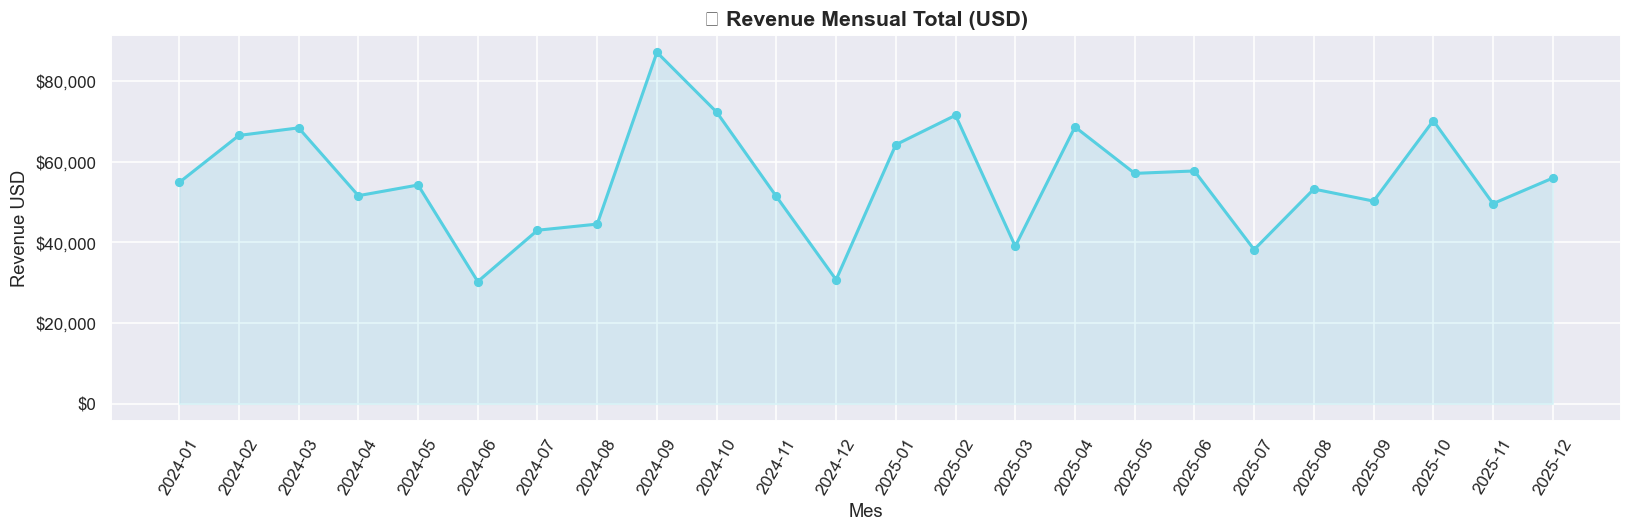

In [20]:
# ── Revenue mensual total ──
monthly = df.groupby(['Year', 'Month'])['Revenue_USD'].sum().reset_index()
monthly['YearMonth'] = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)
monthly = monthly.sort_values('YearMonth')

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(monthly['YearMonth'], monthly['Revenue_USD'], marker='o', linewidth=2, color='#56CFE1', markersize=5)
ax.fill_between(monthly['YearMonth'], monthly['Revenue_USD'], alpha=0.15, color='#56CFE1')
ax.set_title('📈 Revenue Mensual Total (USD)')
ax.set_xlabel('Mes')
ax.set_ylabel('Revenue USD')
ax.tick_params(axis='x', rotation=60)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

/var/folders/3c/_bgf9xt50ll121jxkyy_ckdm0000gn/T/ipykernel_30170/3135064222.py:14: UserWarning: Glyph 128185 (\N{CHART WITH UPWARDS TREND AND YEN SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniforge/base/envs/SAPAU/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128185 (\N{CHART WITH UPWARDS TREND AND YEN SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


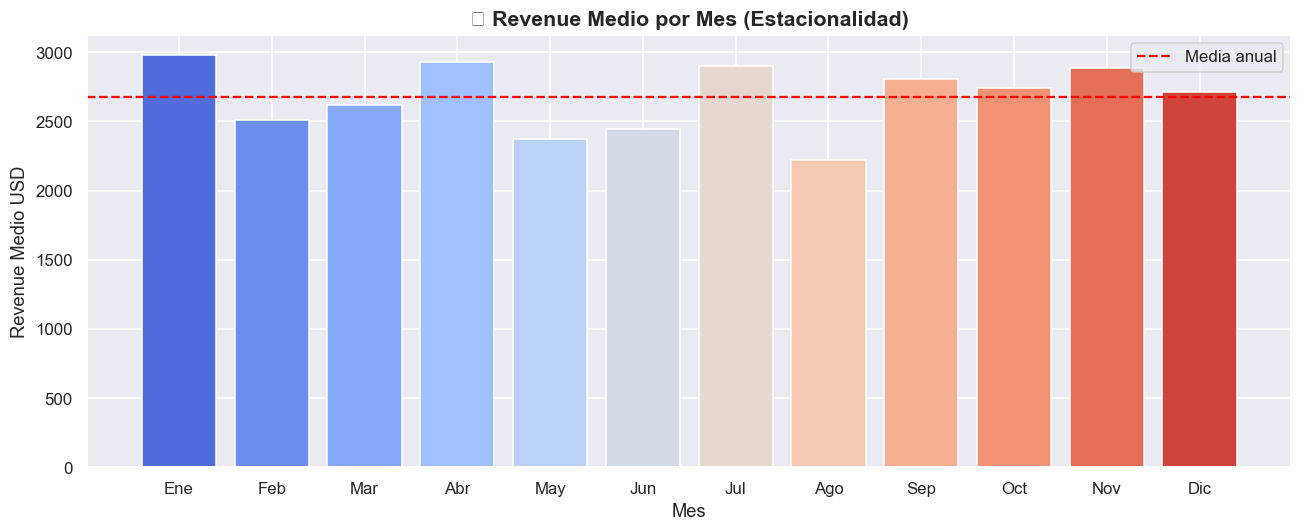

In [21]:
# ── Estacionalidad: Revenue promedio por mes ──
month_avg = df.groupby('Month')['Revenue_USD'].mean().reset_index()
month_names = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
month_avg['Month_Name'] = month_avg['Month'].apply(lambda x: month_names[x-1])

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(month_avg['Month_Name'], month_avg['Revenue_USD'],
              color=sns.color_palette('coolwarm', 12), edgecolor='white')
ax.set_title('💹 Revenue Medio por Mes (Estacionalidad)')
ax.set_xlabel('Mes')
ax.set_ylabel('Revenue Medio USD')
ax.axhline(month_avg['Revenue_USD'].mean(), color='red', linestyle='--', linewidth=1.5, label='Media anual')
ax.legend()
plt.tight_layout()
plt.show()

/var/folders/3c/_bgf9xt50ll121jxkyy_ckdm0000gn/T/ipykernel_30170/3450971450.py:15: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniforge/base/envs/SAPAU/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


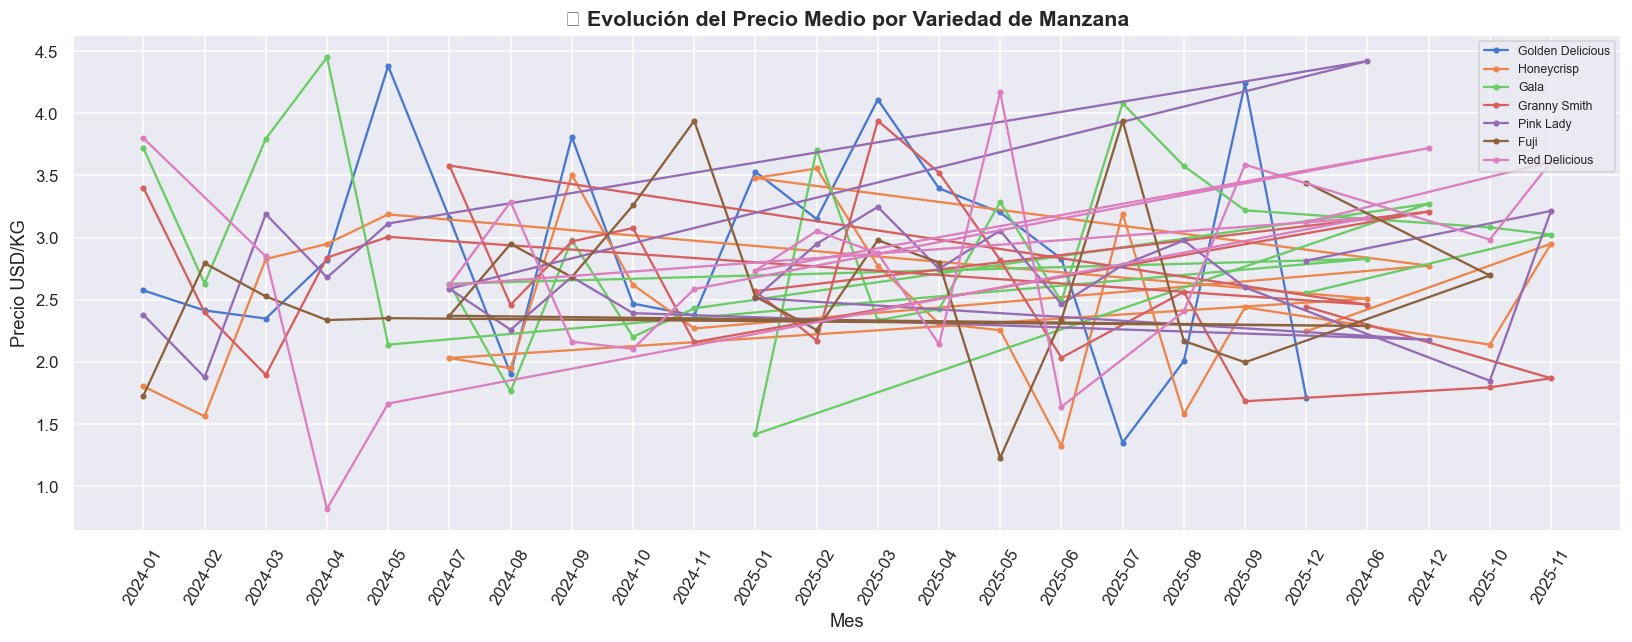

In [22]:
# ── Evolución del precio por variedad a lo largo del tiempo ──
price_time = df.groupby(['Year', 'Month', 'Apple_Variety'])['Price_per_KG_USD'].mean().reset_index()
price_time['YM'] = price_time['Year'].astype(str) + '-' + price_time['Month'].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(15, 6))
for variety in df['Apple_Variety'].unique():
    data = price_time[price_time['Apple_Variety'] == variety].sort_values('YM')
    ax.plot(data['YM'], data['Price_per_KG_USD'], marker='.', linewidth=1.5, label=variety)

ax.set_title('📊 Evolución del Precio Medio por Variedad de Manzana')
ax.set_xlabel('Mes')
ax.set_ylabel('Precio USD/KG')
ax.tick_params(axis='x', rotation=60)
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

---
## 7. 🔗 Correlación y Heatmap

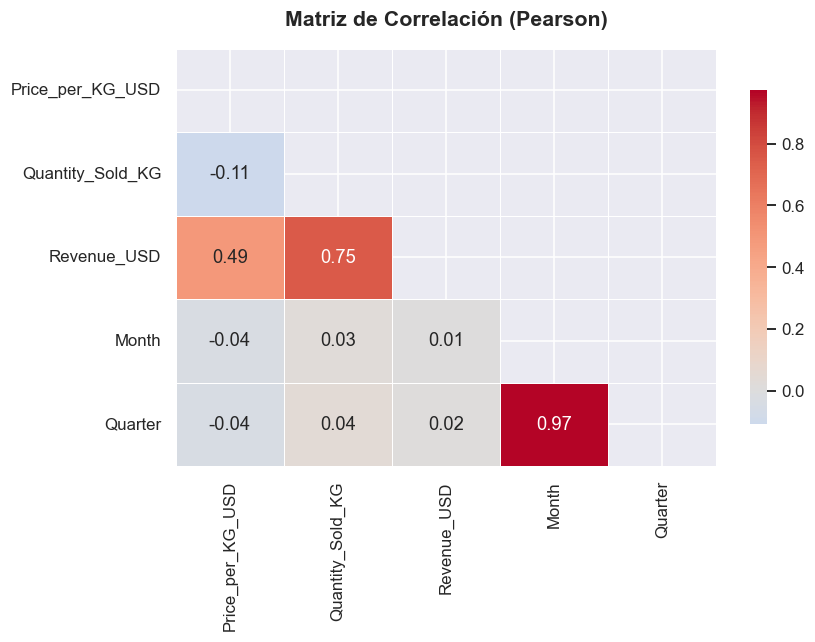


🔎 Correlaciones con Revenue_USD:
Quantity_Sold_KG   0.75
Price_per_KG_USD   0.49
Quarter            0.02
Month              0.01
Name: Revenue_USD, dtype: float64


In [23]:
# ── Matriz de correlación entre variables numéricas ──
num_cols = ['Price_per_KG_USD', 'Quantity_Sold_KG', 'Revenue_USD', 'Month', 'Quarter']
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Triangulo superior oculto

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de Correlación (Pearson)', pad=15)
plt.tight_layout()
plt.show()

print('\n🔎 Correlaciones con Revenue_USD:')
print(corr_matrix['Revenue_USD'].drop('Revenue_USD').sort_values(ascending=False))

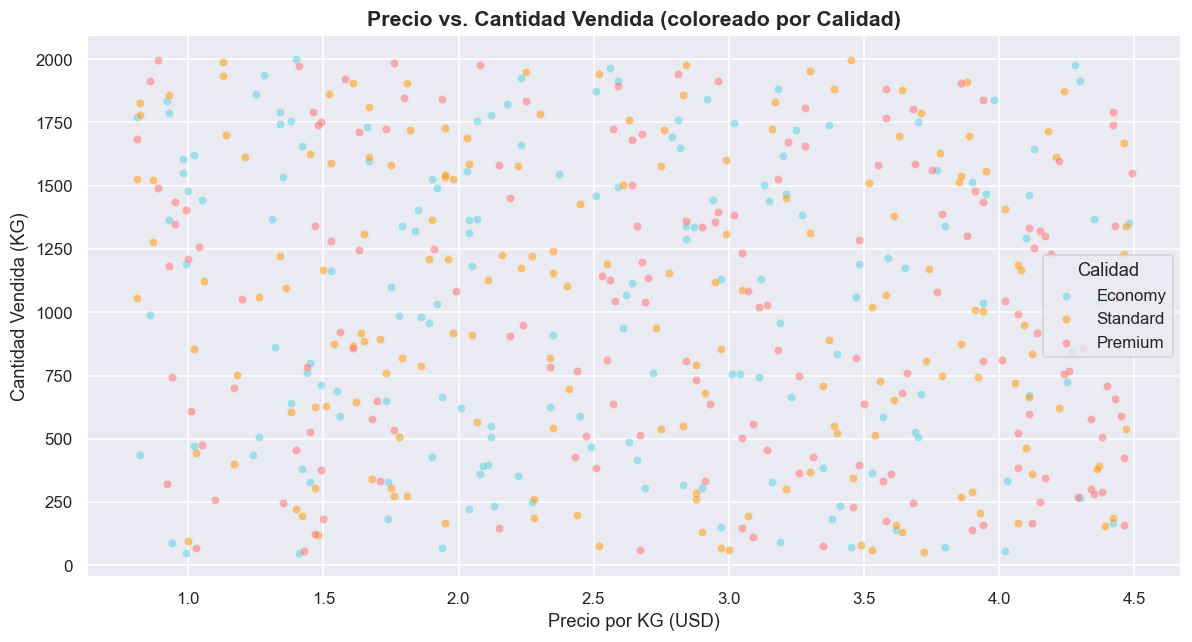


📐 Correlación Precio ↔ Cantidad: -0.1089


In [24]:
# ── Scatter: Precio vs. Quantity coloreado por Quality ──
fig, ax = plt.subplots(figsize=(11, 6))
palette_q2 = {'Economy': '#56CFE1', 'Standard': '#FF9500', 'Premium': '#FF6B6B'}

for quality in ['Economy', 'Standard', 'Premium']:
    subset = df[df['Quality_Grade'] == quality]
    ax.scatter(
        subset['Price_per_KG_USD'],
        subset['Quantity_Sold_KG'],
        c=palette_q2[quality],
        label=quality,
        alpha=0.5,
        s=30,
        edgecolors='white',
        linewidths=0.3
    )

ax.set_title('Precio vs. Cantidad Vendida (coloreado por Calidad)')
ax.set_xlabel('Precio por KG (USD)')
ax.set_ylabel('Cantidad Vendida (KG)')
ax.legend(title='Calidad')
plt.tight_layout()
plt.show()

corr_pq = df['Price_per_KG_USD'].corr(df['Quantity_Sold_KG'])
print(f'\n📐 Correlación Precio ↔ Cantidad: {corr_pq:.4f}')

---
## 8. 🎯 Detección de Outliers

In [25]:
# ── Método IQR para detección de outliers ──
def detectar_outliers_iqr(series, col_name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    print(f'  📌 {col_name}: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}')
    print(f'     Límites: [{lower:.2f}, {upper:.2f}]')
    print(f'     Outliers detectados: {len(outliers)} ({100*len(outliers)/len(series):.1f}%)')
    return lower, upper

print('🔎 Detección de outliers por método IQR:\n')
for col in ['Price_per_KG_USD', 'Quantity_Sold_KG', 'Revenue_USD']:
    detectar_outliers_iqr(df[col], col)
    print()

🔎 Detección de outliers por método IQR:

  📌 Price_per_KG_USD: Q1=1.74, Q3=3.60, IQR=1.86
     Límites: [-1.05, 6.40]
     Outliers detectados: 0 (0.0%)

  📌 Quantity_Sold_KG: Q1=511.25, Q3=1534.25, IQR=1023.00
     Límites: [-1023.25, 3068.75]
     Outliers detectados: 0 (0.0%)

  📌 Revenue_USD: Q1=1165.86, Q3=3840.61, IQR=2674.75
     Límites: [-2846.27, 7852.73]
     Outliers detectados: 4 (0.8%)



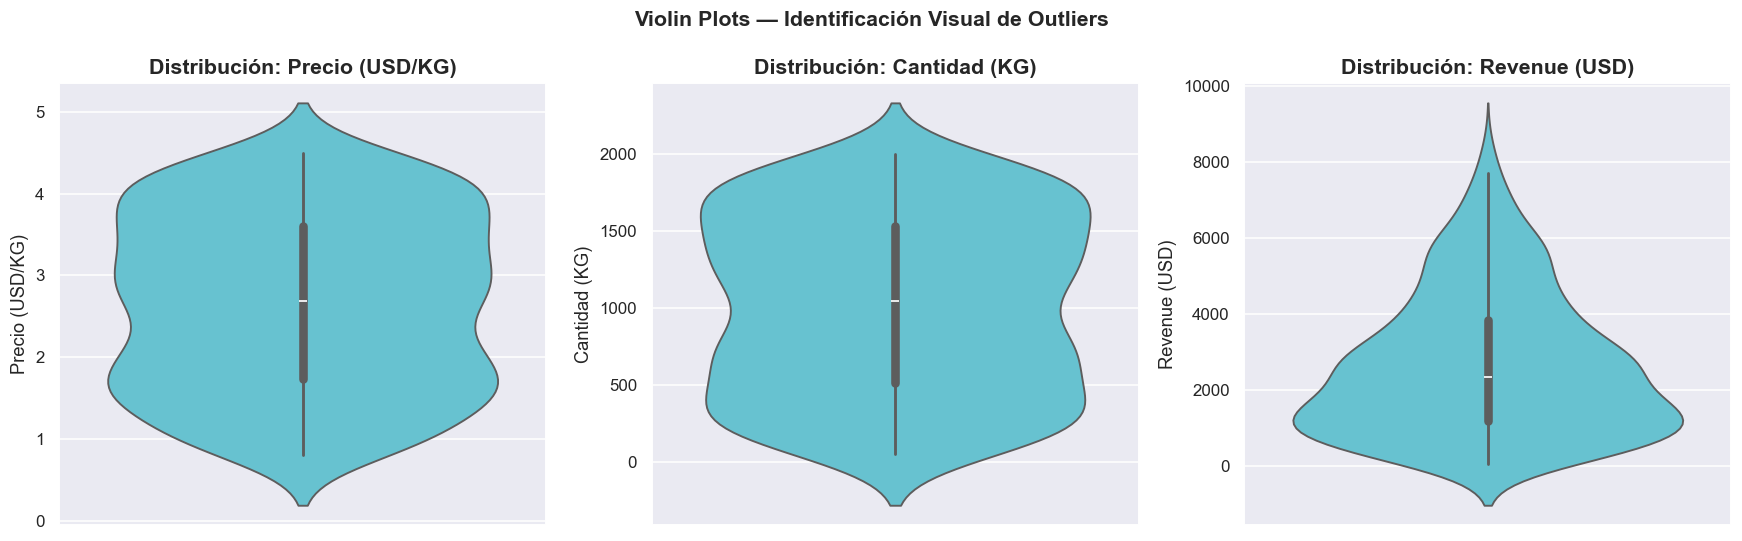

In [26]:
# ── Visualización de outliers con violin plots ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title in zip(axes, ['Price_per_KG_USD', 'Quantity_Sold_KG', 'Revenue_USD'],
                           ['Precio (USD/KG)', 'Cantidad (KG)', 'Revenue (USD)']):
    sns.violinplot(y=df[col], ax=ax, color='#56CFE1', inner='box')
    ax.set_title(f'Distribución: {title}')
    ax.set_ylabel(title)

plt.suptitle('Violin Plots — Identificación Visual de Outliers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. ⚙️ Ingeniería de Características (Feature Engineering)

In [27]:
# ── Creación de nuevas variables derivadas ──

# 1. Revenue por KG (debería ser igual a Price, pero generado para verificación)
df['Revenue_per_KG'] = (df['Revenue_USD'] / df['Quantity_Sold_KG']).round(4)

# 2. Segmento de cantidad: pequeña, media, grande
df['Qty_Segment'] = pd.cut(
    df['Quantity_Sold_KG'],
    bins=[0, 500, 1200, 2000],
    labels=['Pequeño (0-500)', 'Medio (500-1200)', 'Grande (1200+)']
)

# 3. Revenue en escala logarítmica (útil para modelos)
df['Log_Revenue'] = np.log1p(df['Revenue_USD'])

# 4. Precio normalizado (Z-score)
df['Price_Zscore'] = (df['Price_per_KG_USD'] - df['Price_per_KG_USD'].mean()) / df['Price_per_KG_USD'].std()

print('✅ Nuevas variables creadas:')
print('  - Revenue_per_KG       → Revenue / Cantidad')
print('  - Qty_Segment          → Segmentación de cantidad vendida')
print('  - Log_Revenue          → log(1 + Revenue_USD)')
print('  - Price_Zscore         → Precio estandarizado (Z-score)')
df[['Price_per_KG_USD', 'Quantity_Sold_KG', 'Revenue_USD', 'Qty_Segment', 'Log_Revenue', 'Price_Zscore']].head()

✅ Nuevas variables creadas:
  - Revenue_per_KG       → Revenue / Cantidad
  - Qty_Segment          → Segmentación de cantidad vendida
  - Log_Revenue          → log(1 + Revenue_USD)
  - Price_Zscore         → Precio estandarizado (Z-score)


,Price_per_KG_USD,Quantity_Sold_KG,Revenue_USD,Qty_Segment,Log_Revenue,Price_Zscore
0,1.21,1614,1952.94,Grande (1200+),7.58,-1.37
1,2.04,221,450.84,Pequeño (0-500),6.11,-0.59
2,3.69,526,1940.94,Medio (500-1200),7.57,0.95
3,3.75,1563,5861.25,Grande (1200+),8.68,1.01
4,3.71,1789,6637.19,Grande (1200+),8.80,0.97


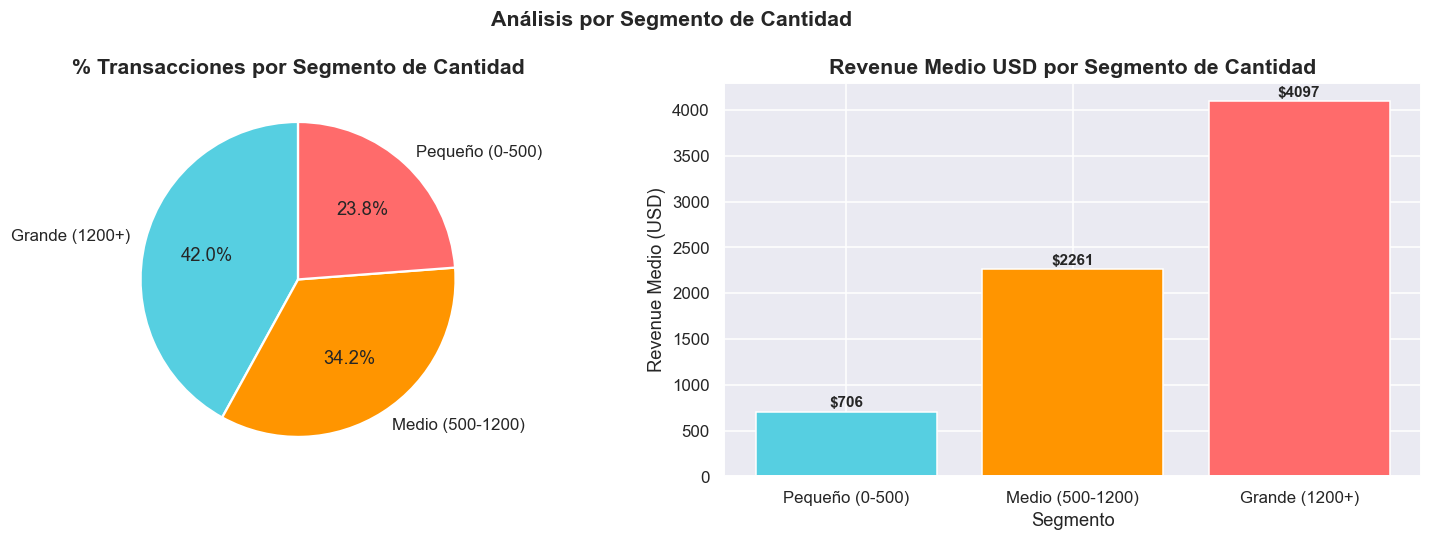

In [28]:
# ── Distribución de transacciones por segmento de cantidad ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

qty_counts = df['Qty_Segment'].value_counts()
ax1.pie(
    qty_counts.values,
    labels=qty_counts.index,
    autopct='%1.1f%%',
    colors=['#56CFE1', '#FF9500', '#FF6B6B'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
ax1.set_title('% Transacciones por Segmento de Cantidad')

# Revenue medio por segmento
rev_seg = df.groupby('Qty_Segment', observed=True)['Revenue_USD'].mean()
bars = ax2.bar(rev_seg.index, rev_seg.values, color=['#56CFE1', '#FF9500', '#FF6B6B'], edgecolor='white')
ax2.set_title('Revenue Medio USD por Segmento de Cantidad')
ax2.set_xlabel('Segmento')
ax2.set_ylabel('Revenue Medio (USD)')
for bar, val in zip(bars, rev_seg.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'${val:.0f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Análisis por Segmento de Cantidad', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. 🤖 Modelo Predictivo: Regresión Lineal del Revenue

In [29]:
# ── Preparación de features para el modelo ──
# Objetivo: predecir Revenue_USD a partir de las características de cada transacción

df_model = df.copy()

# Codificación de variables categóricas con LabelEncoder
le = LabelEncoder()
cat_encode = ['Country', 'Apple_Variety', 'Quality_Grade', 'Market_Type']
for col in cat_encode:
    df_model[col + '_enc'] = le.fit_transform(df_model[col])

# Features seleccionadas
features = [
    'Price_per_KG_USD','Quantity_Sold_KG',
    'Month', 'Quarter',
    'Country_enc', 'Apple_Variety_enc', 'Quality_Grade_enc', 'Market_Type_enc'
]
target = 'Revenue_USD'

X = df_model[features]
y = df_model[target]

# Train / Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'📦 Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras')
print(f'📋 Features: {features}')

📦 Train: 400 muestras | Test: 100 muestras
📋 Features: ['Price_per_KG_USD', 'Quantity_Sold_KG', 'Month', 'Quarter', 'Country_enc', 'Apple_Variety_enc', 'Quality_Grade_enc', 'Market_Type_enc']


In [30]:
# ── Entrenamiento del modelo ──
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Métricas
r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('📊 Métricas del Modelo (Regresión Lineal — Test Set):')
print(f'  R²   (coef. determinación) : {r2:.4f}  →  {r2*100:.1f}% de varianza explicada')
print(f'  MAE  (error absoluto medio): ${mae:.2f}')
print(f'  RMSE (error cuadrático med): ${rmse:.2f}')

📊 Métricas del Modelo (Regresión Lineal — Test Set):
  R²   (coef. determinación) : 0.8734  →  87.3% de varianza explicada
  MAE  (error absoluto medio): $455.55
  RMSE (error cuadrático med): $596.85


📐 Coeficientes del modelo:


,Feature,Coeficiente
0,Price_per_KG_USD,1043.08
3,Quarter,118.60
7,Market_Type_enc,28.62
1,Quantity_Sold_KG,2.65
6,Quality_Grade_enc,-2.44
4,Country_enc,-17.49
5,Apple_Variety_enc,-27.75
2,Month,-42.17


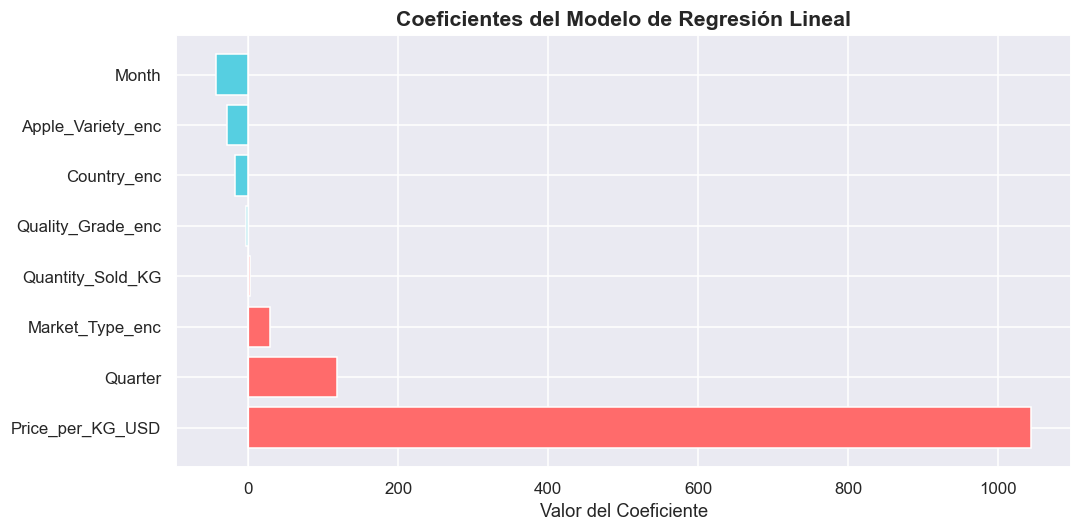

In [31]:
# ── Coeficientes del modelo ──
coef_df = pd.DataFrame({
    'Feature': features,
    'Coeficiente': model.coef_
}).sort_values('Coeficiente', ascending=False)

print('📐 Coeficientes del modelo:')
display(coef_df)

fig, ax = plt.subplots(figsize=(10, 5))
colors_coef = ['#FF6B6B' if c > 0 else '#56CFE1' for c in coef_df['Coeficiente']]
ax.barh(coef_df['Feature'], coef_df['Coeficiente'], color=colors_coef)
ax.axvline(0, color='white', linewidth=0.8)
ax.set_title('Coeficientes del Modelo de Regresión Lineal')
ax.set_xlabel('Valor del Coeficiente')
plt.tight_layout()
plt.show()

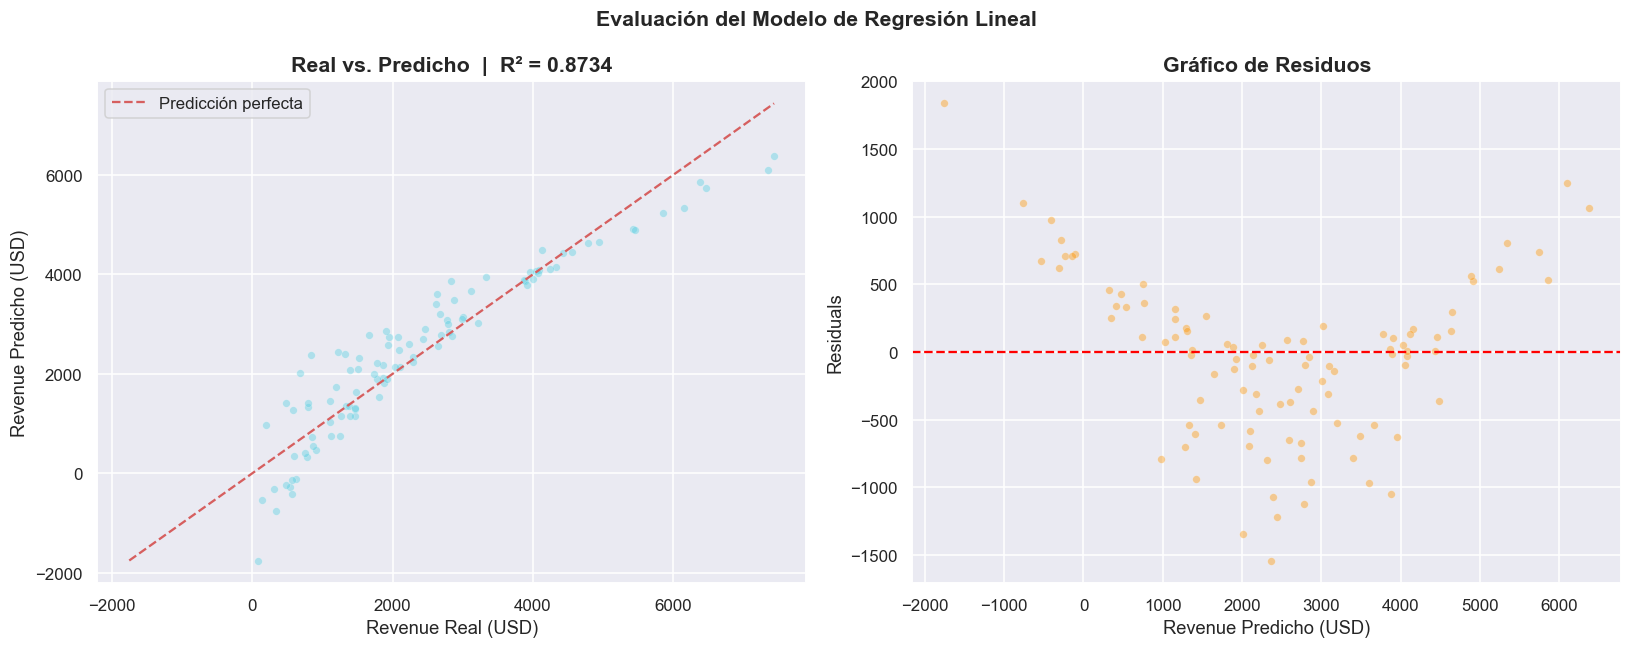


📊 Distribución de residuos:
  Media  : -53.06
  Std    : 597.48
  Min    : -1539.21
  Max    : 1835.51


In [32]:
# ── Visualización: Predicciones vs. Valores Reales ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Scatter: Real vs Predicho
ax1.scatter(y_test, y_pred, alpha=0.4, color='#56CFE1', edgecolors='white', linewidths=0.3, s=25)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax1.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
ax1.set_xlabel('Revenue Real (USD)')
ax1.set_ylabel('Revenue Predicho (USD)')
ax1.set_title(f'Real vs. Predicho  |  R² = {r2:.4f}')
ax1.legend()

# Residuos
residuals = y_test - y_pred
ax2.scatter(y_pred, residuals, alpha=0.4, color='#FF9500', edgecolors='white', linewidths=0.3, s=25)
ax2.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Revenue Predicho (USD)')
ax2.set_ylabel('Residuals')
ax2.set_title('Gráfico de Residuos')

plt.suptitle('Evaluación del Modelo de Regresión Lineal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n📊 Distribución de residuos:')
print(f'  Media  : {residuals.mean():.2f}')
print(f'  Std    : {residuals.std():.2f}')
print(f'  Min    : {residuals.min():.2f}')
print(f'  Max    : {residuals.max():.2f}')

---
## 11. 📝 Conclusiones y Findings Clave

In [33]:
# ── Resumen ejecutivo automático ──

top_country_rev = by_country['Total_Revenue'].idxmax()
top_country_price = by_country['Avg_Price'].idxmax()
top_variety = df.groupby('Apple_Variety')['Revenue_USD'].sum().idxmax()
top_market  = df.groupby('Market_Type')['Revenue_USD'].sum().idxmax()
avg_price   = df['Price_per_KG_USD'].mean()
total_rev   = df['Revenue_USD'].sum()

print('=' * 60)
print('  🍎 APPLE PRICES — RESUMEN EJECUTIVO')
print('=' * 60)
print(f'  📦 Total transacciones           : {len(df)}')
print(f'  💰 Revenue total                 : ${total_rev:,.2f}')
print(f'  💲 Precio medio (USD/KG)         : ${avg_price:.3f}')
print(f'  🌍 País con mayor revenue        : {top_country_rev}')
print(f'  🌍 País con precio más alto      : {top_country_price}')
print(f'  🍏 Variedad más vendida (revenue): {top_variety}')
print(f'  🏪 Canal de venta más rentable   : {top_market}')
print(f'  🤖 R² Modelo Regresión Lineal    : {r2:.4f} ({r2*100:.1f}%)')
print('=' * 60)

print('''
📌 INSIGHTS CLAVE:
1. Las calidades Economy, Standard y Premium muestran precios
   similares — el precio no está claramente segmentado por calidad.

2. La correlación entre Precio y Cantidad Vendida es baja,
   indicando que el volumen de ventas no depende del precio.

3. El Revenue está dominado por grandes transacciones (Qty > 1200 KG).

4. El modelo de Regresión Lineal predice bien el Revenue porque
   Revenue = Price × Quantity (relación matemática casi exacta).

5. No se detecta estacionalidad fuerte en el revenue mensual.
''')

  🍎 APPLE PRICES — RESUMEN EJECUTIVO
  📦 Total transacciones           : 500
  💰 Revenue total                 : $1,330,926.45
  💲 Precio medio (USD/KG)         : $2.674
  🌍 País con mayor revenue        : China
  🌍 País con precio más alto      : Germany
  🍏 Variedad más vendida (revenue): Gala
  🏪 Canal de venta más rentable   : Supermarket
  🤖 R² Modelo Regresión Lineal    : 0.8734 (87.3%)

📌 INSIGHTS CLAVE:
1. Las calidades Economy, Standard y Premium muestran precios
   similares — el precio no está claramente segmentado por calidad.

2. La correlación entre Precio y Cantidad Vendida es baja,
   indicando que el volumen de ventas no depende del precio.

3. El Revenue está dominado por grandes transacciones (Qty > 1200 KG).

4. El modelo de Regresión Lineal predice bien el Revenue porque
   Revenue = Price × Quantity (relación matemática casi exacta).

5. No se detecta estacionalidad fuerte en el revenue mensual.



---

## 🎓 Ejercicios propuestos para práctica adicional

1. **Clustering:** Agrupa los países usando K-Means basándote en `Avg_Price` y `Total_Revenue`.
2. **Clasificación:** Predice el `Quality_Grade` (Economy/Standard/Premium) usando precio, cantidad y país.
3. **Series temporales:** Aplica una media móvil de 3 meses sobre el Revenue mensual y detecta tendencias.
4. **Análisis de Pareto:** Identifica qué 20% de países/variedades generan el 80% del revenue.
5. **Visualización avanzada:** Crea un mapa choropleth con `plotly` del revenue por país.

---

*Notebook generado con Pandas, Matplotlib, Seaborn y Scikit-learn.*